<a href="https://colab.research.google.com/github/KarenMaldonadoVasquez/P01---Behavioral-Finance/blob/main/p01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULATOR TRADING RECORDS**
## *Primera parte: Creación de datos*


### **Inversionistas**

In [11]:
import numpy as np
import pandas as pd

# Generar números aleatorios, el 42 ayuda a producir exactamente la misma secuencia de números "aleatorios" cada vez que se ejecute
rng = np.random.default_rng(42)

# Definimos el tamaño de la población de inversores
N = 1000

# Construimos el DataFrame 'inversionistas' que almacena las características de cada uno
inversionistas = pd.DataFrame({
    # {Odean (1998) / Account Identifier}
    # Identificador único numérico para cada inversor
    "id": np.arange(1, N + 1), #np.arange solo hace una lista de números de 1 a 1000

    # 'delta' representa la intensidad del Efecto Disposición (mu) inyectado, generado uniformemente en
    "delta": rng.uniform(0, 1, N), # rng.uniform genera número de forma uniforme de 0 a 1

    # 'kappa' representa la intensidad de la Sobreconfianza (gamma) inyectada, generada uniformemente en [1]
    "kappa": rng.uniform(0, 1, N),

    # Asignación aleatoria uniforme del capital monetario inicial entre $10,000 y $500,000 USD
    "capital_inicial": rng.uniform(10_000, 500_000, N).round(2),

    # Cantidad discreta de acciones diferentes (entre 5 y 30) que el inversor mantendrá en su portafolio
    "num_posiciones": rng.integers(5, 31, N)#rng.integers generador de números enteros de 1 a 30
})

print(inversionistas.head())
print(inversionistas.describe())
inversionistas.to_csv("inversionistas.csv", index=False)

   id     delta     kappa  capital_inicial  num_posiciones
0   1  0.773956  0.062063        422938.66              21
1   2  0.438878  0.458262        228730.85              26
2   3  0.858598  0.129030        476957.83              21
3   4  0.697368  0.152327        328889.35              20
4   5  0.094177  0.632283         66790.44              17
                id        delta        kappa  capital_inicial  num_posiciones
count  1000.000000  1000.000000  1000.000000      1000.000000     1000.000000
mean    500.500000     0.497178     0.508496    251507.988790       16.833000
std     288.819436     0.291586     0.289343    141890.009033        7.529263
min       1.000000     0.001233     0.000519     10485.100000        5.000000
25%     250.750000     0.240259     0.249506    129917.977500       10.000000
50%     500.500000     0.494824     0.496504    252767.795000       17.000000
75%     750.250000     0.758893     0.763053    375500.275000       23.000000
max    1000.000000    

### **Matrices de precios de acciones**

In [18]:
# {P01.pdf / Configuración de la Simulación}
# Definimos las dimensiones del mercado: 50 acciones y 500 días de simulación
n_acciones = 50
n_dias = 500

# {Odean (1998) / Punto de Referencia Inicial}
# Fijamos el precio inicial de $100.0 USD para todas las acciones en el Día 0 para estandarizar la escala
precio_inicial = 100.0

# Generamos los rendimientos diarios aleatorios (cambios porcentuales) para cada acción y cada día.
# 'loc=0.0005' es el crecimiento diario promedio (0.05%) y 'scale=0.015' es la fluctuación diaria (1.5%)
retornos_diarios = rng.normal(loc=0.0005, scale=0.015, size=(n_dias, n_acciones))

# Creamos una matriz vacía de 501 filas (Día 0 al 500) y 50 columnas (una por cada acción)
precios = np.zeros((n_dias + 1, n_acciones)) #np.zeros crea una matriz básica llena de 0 sólo para que no esté vacía

# Asignamos el precio inicial de $100.0 a la primera fila (Día 0) para todas las acciones
precios[0, :] = precio_inicial

# RANDOM WALK para calcular el precio de cada día
# Fórmula: Precio de Hoy = Precio de Ayer * (1 + Crecimiento/Caída del Día)
for dia in range(1, n_dias + 1): #ciclo para que haga lo mismo desde el día 1 - 500
    precios[dia, :] = precios[dia - 1, :] * (1 + retornos_diarios[dia - 1, :]) #precios[dia - 1, :] busca el precio del día anterior
                                            # * (1 + retornos_diarios[dia - 1, :] se multiplica el p de ayer por el facotr crecimiento o caida de hoy
                                            # ej: si la acción sube 2% la formula sería precio de ayer * 1.02, ése se´ria el precio nuevo


# Convertimos la matriz a tabla de pandas y le asignamos los nombres
columnas = [f"Stock_{i+1}" for i in range(n_acciones)]
df_precios = pd.DataFrame(precios, columns=columnas)

# Verificamos dimensiones y resultados
print("Dimensiones de la matriz de precios:", df_precios.shape)
df_precios.to_csv("precios_mercado.csv", index_label="Dia")

Dimensiones de la matriz de precios: (501, 50)


In [19]:
df_precios.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10,...,Stock_41,Stock_42,Stock_43,Stock_44,Stock_45,Stock_46,Stock_47,Stock_48,Stock_49,Stock_50
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,99.398723,100.225148,100.434825,99.134277,100.067798,97.783282,100.934266,100.467594,100.316967,99.596513,...,101.332091,99.481775,99.333912,100.284938,99.881573,100.160752,100.121271,100.546777,100.311145,100.908755
2,98.940272,101.346134,99.955156,102.528891,101.942812,100.469356,100.953547,99.189904,96.338305,98.096458,...,101.547494,97.896241,98.603094,102.723216,98.569070,100.731592,99.833817,102.281875,98.163879,100.059345
3,96.766645,100.524023,101.224487,99.908967,100.539995,99.313455,100.538477,98.510347,96.569745,99.255676,...,97.860053,98.535796,98.829438,100.524149,98.045546,101.285897,98.415452,102.724590,97.056489,98.994877
4,95.954601,101.752909,103.377677,100.835442,99.795568,100.119724,101.751707,98.411429,95.254675,101.931975,...,96.246094,100.115922,98.300322,100.007420,96.712387,99.240896,97.000478,101.409060,96.418244,100.377238


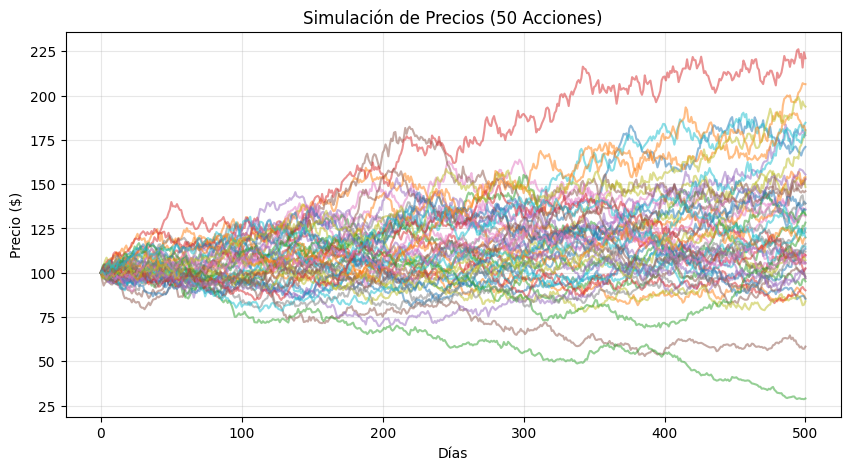

In [20]:
import matplotlib.pyplot as plt

df_precios.plot(legend=False, figsize=(10, 5), alpha=0.5, title="Simulación de Precios (50 Acciones)")
plt.xlabel("Días")
plt.ylabel("Precio ($)")
plt.grid(True, alpha=0.3)
plt.show()

La matriz de precios creada se generó mediante un proceso de paseo aleatorio estocástico (Random Walk) sencillo. Este genera el precio de 50 acciones para 500 días exactamente.

Para el día 0 se fijó un precio inicial de 100 USD ($P_0 = 100$) para todos los activos, ya que esto facilita la identificación de ganncias/pérdidas sin un sesgo nominal de escala (mostrado en el paper: "The Journal of Finance - 2002, Odean - Are Investors Reluctant to Realize Their Losses").  Además, los parámetros usados para definir la Dist.normal de los precios fueron de:

* Retorno medio de 0.05% lo que equivale a un rendimiento anualizado aproximado del 12.6% $$(0.05\% \times 252)$$

* Volatilidad diaria del 1.5% equivalente a una volatilidad anualizada de 23.8% $$(1.5\% \times \sqrt{252})$$

Los cuales equivalen a el comportamiento histórico "normal" de las acciones. Por otra parte, la gráfica de los precios nos indica que en $t_0$ existe un precio de referencia inicial estandarizado, también una dispersión temporal en forma de abanico que muestra el incremento de activos con alto rendimeinto, y una densidad central concentrada entre 75 y 150 USD que confirma que los precios son independientes de las decisiones de compra/venta de los inversionistas.



### **Portafolio inicial por inversionista ($S_0$)**

In [26]:
# Función para construir el port.inicial
def crear_portafolio_inicial(df_inv, df_p): #crea dos tablas df_inv será inversionistas df_p es los precios
    # Extraemos la lista con los nombres de las 50 acciones disponibles
    lista_acciones = list(df_p.columns)

    # Lista vacía donde iremos almacenando cada compra realizada en el Día 0
    posiciones_iniciales = []

    # Recorremos la tabla de los 1,000 inversores fila por fila
    for _, inv in df_inv.iterrows():
        # Extraemos el id, capital inicial y cantidad de acciones a comprar de inversionistas
        id_inv = int(inv["id"])
        capital = inv["capital_inicial"]
        n_pos = int(inv["num_posiciones"])

        # {Barber & Odean (2000) / Selección Aleatoria}
        acciones_elegidas = rng.choice(lista_acciones, size=n_pos, replace=False) #rng.choice selecciona al azar acciones para crear en cuales si invertirá cada inversionista

        # Divide el capital en partes iguales entre la cantidad de acciones elegidas
        capital_por_accion = capital / n_pos

        # Registro de la compra de cada acción
        for accion in acciones_elegidas:
            # {Odean (1998) / Punto de Referencia Base}
            # Obtenemos el precio de compra en el Día 0=100
            precio_compra = df_p.loc[0, accion]

            # Calculamos la cantidad de acciones compradas (Dinero asignado / 100)
            titulos = capital_por_accion / precio_compra

            # {Odean (1998) / Registro de Contabilidad Mental}
            # Guardamos la posición individual que servirá como precio de compra de referencia
            #aqui creamos las partes de nuestra tabla para el portafolio
            posiciones_iniciales.append({
                "id_inversor": id_inv,         # Número de cuenta del inversor (1 al 1000)
                "accion": accion,              # Nombre de la acción adquirida (ej. 'Stock_12')
                "titulos": titulos,            # Cantidad de títulos comprados
                "precio_compra": precio_compra,# Precio inicial de compra ($100.00 USD)
                "dia_compra": 0                # Día de la transacción (Día 0)
            })

    # Se transforma la lista en tabla
    return pd.DataFrame(posiciones_iniciales)
# Especificamos los datos que debe usar el portafolio
df_portafolio_dia0 = crear_portafolio_inicial(inversionistas, df_precios)

# Verificamos resultados
df_portafolio_dia0.to_csv("portafolio_inicial_dia0.csv", index=False)
print(df_portafolio_dia0.describe())

        id_inversor       titulos  precio_compra  dia_compra
count  16833.000000  16833.000000        16833.0     16833.0
mean     505.376522    149.413645          100.0         0.0
std      291.645060    128.884959            0.0         0.0
min        1.000000      5.148436          100.0         0.0
25%      248.000000     63.890787          100.0         0.0
50%      504.000000    120.005021          100.0         0.0
75%      763.000000    190.274100          100.0         0.0
max     1000.000000    989.310100          100.0         0.0


In [25]:
df_portafolio_dia0.head()

,id_inversor,accion,titulos,precio_compra,dia_compra
0,1,Stock_23,201.399362,100.0,0
1,1,Stock_4,201.399362,100.0,0
2,1,Stock_18,201.399362,100.0,0
3,1,Stock_49,201.399362,100.0,0
4,1,Stock_10,201.399362,100.0,0


El portafolio inicial que creamos distribuye el capital que le asignamos anteriormente a todos los inversionistas de forma equitativa entre los activos que tienen cada uno varía entre 5 y 30 acciones, todo asignado por medio de un muestreo aleatorio uniforme. La simulación creó $16, 833$ de posiciones de compra por tanto existe un promedio de 16.8 acciones por inversionista aproximadamente. El número de titulos que compran los inversionista varía mucho dada las posibilidades y movimientos que fueron aleatorios para cada inversionista, depende de su capital y como quiso repartirlo entre las acciones.

##*Second Part: Decision rules*

Ejecución de los escenarios

In [27]:
# Usamos directamente el 'rng' global definido al inicio de tu cuaderno
def simular_escenario(delta_val, kappa_val, p_base=0.015, confound=None):
    # Copia de las 16,833 posiciones iniciales del Día 0
    pos = df_portafolio_dia0.copy()

    # Extraemos arreglos numéricos para ejecución rápida
    inv_ids = pos["id_inversor"].values
    acciones = pos["accion"].values
    precios_compra = pos["precio_compra"].values
    activas = np.ones(len(pos), dtype=bool)

    # Mapeo directo a la matriz de precios existente
    stock_col_map = {col: i for i, col in enumerate(df_precios.columns)}
    accion_indices = np.array([stock_col_map[a] for a in acciones])
    precios_matrix = df_precios.values # Matriz de precios de 500 días

    # Contadores acumulados para las métricas de Odean (1998)
    RG, PG, RL, PL = 0, 0, 0, 0
    total_trades = 0

    # Factor de frecuencia por sobreconfianza (kappa)
    freq_factor = 1.0 + 1.5 * kappa_val

    # {P01.pdf / Bucle Diario}
    for dia in range(1, 501):
        if not np.any(activas):
            break

        precios_hoy = precios_matrix[dia, accion_indices]

        # Identificamos ganancias y pérdidas no realizadas
        es_ganancia = precios_hoy > precios_compra
        es_perdida = precios_hoy < precios_compra

        # Probabilidades de venta según el escenario
        p_venta = np.zeros(len(pos))

        if confound == "rebalancing":
            p_venta[es_ganancia] = p_base * (1.0 + 0.5) * freq_factor
            p_venta[es_perdida] = p_base * freq_factor
        elif confound == "mean_reversion":
            p_venta[es_ganancia] = p_base * (1.0 + 0.6) * freq_factor
            p_venta[es_perdida] = p_base * (1.0 - 0.4) * freq_factor
        else:
            p_venta[es_ganancia] = p_base * (1.0 + delta_val) * freq_factor
            p_venta[es_perdida] = p_base * (1.0 - delta_val) * freq_factor

        p_venta = np.clip(p_venta, 0.0, 1.0)

        # USO DIRECTO DE TU 'rng' GLOBAL (sin semillas ni objetos locales)
        u = rng.random(len(pos))
        se_vende = activas & (u < p_venta)

        # Conteo de Odean (1998)
        vendedores_hoy = np.unique(inv_ids[se_vende])

        if len(vendedores_hoy) > 0:
            mask_inversores_activos_hoy = np.isin(inv_ids, vendedores_hoy) & activas

            rg_today = np.sum(se_vende & es_ganancia)
            rl_today = np.sum(se_vende & es_perdida)

            se_mantiene = mask_inversores_activos_hoy & (~se_vende)

            pg_today = np.sum(se_mantiene & es_ganancia)
            pl_today = np.sum(se_mantiene & es_perdida)

            RG += rg_today
            RL += rl_today
            PG += pg_today
            PL += pl_today
            total_trades += np.sum(se_vende)

        activas[se_vende] = False

    pgr = RG / (RG + PG) if (RG + PG) > 0 else 0.0
    plr = RL / (RL + PL) if (RL + PL) > 0 else 0.0

    return {
        "RG": RG,
        "PG": PG,
        "RL": RL,
        "PL": PL,
        "PGR": round(pgr, 4),
        "PLR": round(plr, 4),
        "PGR-PLR": round(pgr - plr, 4),
        "Total_Trades": total_trades
    }

In [31]:
escenarios = {
    "Escenario 1 (Caso Nulo)": (0.0, 0.0, None),
    "Escenario 2 (Disposición Baja)": (0.3, 0.0, None),
    "Escenario 3 (Disposición Alta)": (0.8, 0.0, None),
    "Escenario 4 (Turnover Bajo)": (0.0, 0.3, None),
    "Escenario 5 (Turnover Alto)": (0.0, 0.8, None),
    "Escenario 6 (Ambos Activos)": (0.8, 0.8, None),
    "Escenario 7 (Confusor: Rebalanceo)": (0.0, 0.0, "rebalancing"),
    "Escenario 8 (Confusor: Reversión)": (0.0, 0.0, "mean_reversion")
}

resultados = []

for nombre, (delta_val, kappa_val, c_type) in escenarios.items():
    m = simular_escenario(delta_val, kappa_val, p_base=0.015, confound=c_type)
    m["Escenario"] = nombre
    m["delta"] = delta_val
    m["kappa"] = kappa_val
    resultados.append(m)

df_resumen_8_escenarios = pd.DataFrame(resultados)

columnas_orden = [
    "Escenario", "delta", "kappa", "RG", "PG", "RL", "PL",
    "PGR", "PLR", "PGR-PLR", "Total_Trades"
]

print("TABLA RESUMEN DE LOS 8 ESCENARIOS")
print(df_resumen_8_escenarios[columnas_orden].to_string(index=False))

TABLA RESUMEN DE LOS 8 ESCENARIOS
                         Escenario  delta  kappa    RG    PG   RL    PL    PGR    PLR  PGR-PLR  Total_Trades
           Escenario 1 (Caso Nulo)    0.0    0.0  9738 81268 7083 63891 0.1070 0.0998   0.0072         16821
    Escenario 2 (Disposición Baja)    0.3    0.0 11328 75157 5495 69132 0.1310 0.0736   0.0573         16823
    Escenario 3 (Disposición Alta)    0.8    0.0 14517 67620 2199 78022 0.1767 0.0274   0.1493         16716
       Escenario 4 (Turnover Bajo)    0.0    0.3  9541 75870 7292 61949 0.1117 0.1053   0.0064         16833
       Escenario 5 (Turnover Alto)    0.0    0.8  9261 70611 7572 57678 0.1159 0.1160  -0.0001         16833
       Escenario 6 (Ambos Activos)    0.8    0.8 14222 56482 2599 72096 0.2011 0.0348   0.1664         16821
Escenario 7 (Confusor: Rebalanceo)    0.0    0.0 10619 74950 6213 66866 0.1241 0.0850   0.0391         16832
 Escenario 8 (Confusor: Reversión)    0.0    0.0 12129 71957 4694 71624 0.1442 0.0615   0.0827

## Análisis de comportamiento del portafolio según cada escenario:



### ***Escenario 1 (Caso Nulo)***

Este escenario significa que el inversor es completamente neutral. En nuestro portafolio la venta de las acciones que generan ganancias y pérdidas se comportan casi igual con un valor de casi 10% para ambas, por lo que su diferencia es cercana a cero, casi nula. Por tanto, si los inversionistas no tienen sesgos su venta de las acciones son equivalentes sea cual sea su rendimiento.


### ***Escenario 2 (Disposición Baja)***

Este escenario significa que el inversor tiene un sesgo de disposición leve. En nuestro portafolio la venta de acciones que generan ganancias sube al 13% mientras que la de pérdidas cae al 7.5%, por lo que su diferencia aumenta a 0.055. Por tanto, cuando existe una ligera inclinación psicológica, el inversor empieza a vender un poco más rápido sus ganadoras mientras mantiene en cartera las acciones que van perdiendo.

### ***Escenario 3 (Disposición Alta)***

Este escenario significa que el inversor tiene un sesgo de disposición muy marcado. En nuestro portafolio la venta de acciones ganadoras se dispara al 17.7% mientras que las ventas con pérdida caen drásticamente al 2.7%, generando una diferencia muy amplia de casi 0.15. Por tanto, se evidencia con claridad cómo el inversor se apresura a asegurar sus ganancias pero congela y aguanta casi la totalidad de sus acciones en pérdida.

### ***Escenario 4 (Turnover Bajo)***
Este escenario significa que el inversor opera con una sobreconfianza leve pero sin sesgos de disposición. En nuestro portafolio la venta de acciones en ganancia es de 11% y en pérdida es de 10.5%, por lo que su diferencia vuelve a ser cercana a cero con 0.0046\. Por tanto, aumentar ligeramente la frecuencia de operaciones no altera la neutralidad del inversor frente al rendimiento de sus acciones.

### ***Escenario 5 (Turnover Alto)***
Este escenario significa que el inversor opera con mucha sobreconfianza y alta rotación, pero manteniendo la neutralidad sobre sus resultados. En nuestro portafolio las ventas con ganancia (11.6%) y con pérdida (11.7%) son prácticamente idénticas, resultando en una diferencia de -0.0006. Por tanto, se confirma que rotar mucho la cartera por sí solo no genera un falso efecto disposición.

### ***Escenario 6 (Ambos Activos)***
Combina la alta frecuencia de operaciones con una fuerte aversión a perder dinero. El inversor opera mucho y, al mismo tiempo, corre a asegurar cualquier ganancia que ve, lo que dispara la brecha entre $PGR$ y $PLR$ a su punto más alto ($+0.1676$).

### ***Escenario 7 (Confusor: Rebalanceo)***
El inversor no actúa por emoción, sino por una regla técnica para reajustar los pesos de su cartera. Al vender automáticamente las acciones que subieron para no estar sobreexpuesto, la fórmula tradicional detecta un "falso positivo" ($+0.0420$), haciendo parecer que hay un sesgo psicológico cuando en realidad solo hay gestión de riesgo.

### ***Escenario 8 (Confusor: Reversión a la media)***
El inversor cree erróneamente que lo que subió tiene que bajar y lo que cayó tiene que rebotar. Al vender ganadoras esperando su caída, el indicador marca un falso positivo aún mayor ($+0.0830$), lo que demuestra que la métrica de Odean (1998) no logra distinguir entre psicología pura y expectativas sobre la tendencia de los precios.